# GARCH 분석 — 지정학 리스크와 BTC 변동성 (한계점 개선본)
## 지정학적 위기 시 비트코인은 디지털 금인가?
### 캡스톤디자인 | 팀명: 분석많이된다

---

## 한계점 개선 사항

| # | 한계점 | 개선 방법 |
|---|---|---|
| ① | alpha=0 경계 수렴 | alpha bounds 하한 0.0으로 완화 + 이상값 필터링 |
| ② | omega=0 과적합 | omega 하한 1e-4로 강화 |
| ③ | Hessian 수치 미분 오차 | numdifftools Richardson 외삽법 적용 |
| ④ | 국소최적해 (beta=0.30) | 다중 초기값 10개 시도 → 최저 AIC 채택 |

## 필요 파일

```
master_data.csv
```

---
## Step 0. 라이브러리

In [7]:
# numdifftools 설치 (③ 한계점 해결)
!pip install pandas numpy matplotlib scipy numdifftools --quiet


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import t as t_dist, zscore
import warnings, os, platform
warnings.filterwarnings('ignore')

# numdifftools 임포트 (없으면 수치 미분 대체)
try:
    import numdifftools as nd
    USE_NUMDIFF = True
    print('✅ numdifftools 사용 가능 → 정밀 Hessian 계산')
except ImportError:
    USE_NUMDIFF = False
    print('⚠️ numdifftools 없음 → 중앙차분법 fallback')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130

EVENT_DATES = {
    'hormuz_crisis'          : '2019-06-13',
    'soleimani_assassination': '2020-01-03',
    'russia_ukraine_war'     : '2022-02-24',
    'israel_hamas_war'       : '2023-10-07',
    'israel_iran'            : '2024-04-01',
    'us_israel_iran'         : '2026-02-28',
}
EVENT_LABELS = {
    'hormuz_crisis'          : '호르무즈 위기',
    'soleimani_assassination': '솔레이마니 암살',
    'russia_ukraine_war'     : '러-우 전쟁',
    'israel_hamas_war'       : '이스라엘-하마스',
    'israel_iran'            : '이스라엘-이란 충돌',
    'us_israel_iran'         : '이란 전쟁',
}
MODEL_EXOG = {
    'Model1': ['GPR_zscore_scaled'],
    'Model2': ['GPR_custom_scaled'],
    'Model3': ['VIX_scaled', 'fear_greed_lag1_scaled'],
    'Model4': ['GPR_zscore_scaled', 'VIX_scaled', 'fear_greed_lag1_scaled'],
    'Model5': ['GPR_custom_scaled', 'VIX_scaled', 'fear_greed_lag1_scaled'],
}
MODEL_LABELS = {
    'Model1': 'GPR 공식지수 단독',
    'Model2': 'GPR 커스텀지수 단독',
    'Model3': 'VIX + 탐욕지수',
    'Model4': 'GPR 공식 + VIX + 탐욕',
    'Model5': 'GPR 커스텀 + VIX + 탐욕',
}
MODEL_COLORS = {
    'Model1': '#E76F51', 'Model2': '#2A9D8F',
    'Model3': '#457B9D', 'Model4': '#F4A261', 'Model5': '#8338EC',
}

print('✅ 환경 설정 완료')

✅ numdifftools 사용 가능 → 정밀 Hessian 계산
✅ 환경 설정 완료


---
## Step 1. master_data.csv 로드

In [9]:
if not os.path.exists('master_data.csv'):
    raise FileNotFoundError('master_data.csv 없음')

master = pd.read_csv('master_data.csv')
master['date'] = pd.to_datetime(master['date'])
num_cols = ['BTC','Gold','TLT','DXY','SP500','NASDAQ',
            'GPR_custom','GPR','GPR_zscore',
            'VIX','fear_greed','fear_greed_lag1']
for col in num_cols:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors='coerce')

if 'GPR_zscore' not in master.columns and 'GPR' in master.columns:
    master['GPR_zscore'] = zscore(master['GPR'].fillna(master['GPR'].mean()))
    print('⚠️ GPR_zscore 없음 → GPR Z-score로 자동 생성')

print(f'✅ master_data: {len(master)}행')
print(f'   기간: {master["date"].min().date()} ~ {master["date"].max().date()}')
print(f'\n이벤트별 거래일:')
print(master.groupby('event_name')['date'].count().to_string())
print(f'\n이벤트명 일치 확인:')
for ev in EVENT_DATES:
    n = (master['event_name'] == ev).sum()
    print(f'  {ev:<30}: {n}행 {"✅" if n > 0 else "❌"}')

✅ master_data: 1827행
   기간: 2019-01-02 ~ 2026-04-30

이벤트별 거래일:
event_name
hormuz_crisis              182
israel_hamas_war           260
israel_iran                299
russia_ukraine_war         475
soleimani_assassination    339
us_israel_iran             272

이벤트명 일치 확인:
  hormuz_crisis                 : 182행 ✅
  soleimani_assassination       : 339행 ✅
  russia_ukraine_war            : 475행 ✅
  israel_hamas_war              : 260행 ✅
  israel_iran                   : 299행 ✅
  us_israel_iran                : 272행 ✅


---
## Step 2. 데이터 준비

In [10]:
order = list(EVENT_DATES.keys())
master['_order'] = master['event_name'].map({ev:i for i,ev in enumerate(order)})
master_sorted = master.sort_values(['_order','date']).reset_index(drop=True)

exog_cols_all = ['GPR_custom','GPR_zscore','VIX','fear_greed_lag1']
master_final = master_sorted.dropna(subset=['BTC']+exog_cols_all).copy()
master_final['returns_pct'] = master_final['BTC'] * 100

for col in exog_cols_all:
    mu, sig = master_final[col].mean(), master_final[col].std()
    master_final[f'{col}_scaled'] = (master_final[col]-mu)/sig if sig>0 else 0.0

print(f'✅ 분석 대상: {len(master_final)}거래일')
print(master_final.groupby('event_name')['date'].count().to_string())

✅ 분석 대상: 1821거래일
event_name
hormuz_crisis              181
israel_hamas_war           259
israel_iran                298
russia_ukraine_war         474
soleimani_assassination    338
us_israel_iran             271


---
## Step 3. 개선된 GARCH-X 함수

### 개선 사항

```
[개선 ①] alpha 하한 0.0으로 완화 + t-stat 이상값 필터
  기존: bounds alpha = (1e-6, 0.5)
  수정: bounds alpha = (0.0,   0.5)  → 경계 수렴 자연 허용
        t-stat > 100이면 SE 신뢰 불가로 표시

[개선 ②] omega 하한 1e-4로 강화
  기존: bounds omega = (1e-6, None)
  수정: bounds omega = (1e-4, None)  → omega=0 과적합 차단

[개선 ④] 다중 초기값 10개 시도 → 최저 AIC 채택
  alpha_inits × beta_inits 격자 탐색
  → 국소최적해 탈출 가능성 대폭 향상
```

In [11]:
def run_garch_x_improved(y_series, exog_df, model_exog_cols,
                          model_name='Model'):
    """
    한계점 ①②④ 개선된 GARCH(1,1)-X MLE
    h(t) = ω + α·ε²(t-1) + β·h(t-1) + Σγ_k·X_k(t-1)
    """
    # 컬럼 매칭
    actual_cols = [c for c in model_exog_cols if c in exog_df.columns]
    miss = [c for c in model_exog_cols if c not in exog_df.columns]
    if miss:
        print(f'  ⚠️ [{model_name}] 없는 컬럼: {miss}')
    print(f'\n[{model_name}] 외생변수: {actual_cols}')

    y = y_series.dropna().astype(np.float64)
    y_vals = y.values
    T, K = len(y_vals), len(actual_cols)

    if K > 0:
        X_raw = exog_df.loc[y.index, actual_cols].ffill().fillna(0).astype(np.float64)
        X_lag = X_raw.shift(1).fillna(0).values
    else:
        X_lag = np.zeros((T, 0))

    # ── 음의 로그우도 ─────────────────────────────────
    def neg_loglik(params):
        mu, omega, alpha, beta = params[0], params[1], params[2], params[3]
        gamma = params[4:4+K]
        nu    = params[4+K]
        if omega <= 0 or alpha < 0 or beta < 0: return 1e10
        if alpha + beta >= 0.9999: return 1e10
        if nu <= 2.01: return 1e10

        e = y_vals - mu
        h = np.empty(T)
        h[0] = max(np.var(e), 1e-8)
        for t in range(1, T):
            eff = float(np.dot(gamma, X_lag[t])) if K > 0 else 0.0
            h[t] = omega + alpha*e[t-1]**2 + beta*h[t-1] + eff
            if h[t] <= 1e-8: h[t] = 1e-8

        ll = (gammaln((nu+1)/2) - gammaln(nu/2)
              - 0.5*np.log(np.pi*(nu-2)) - 0.5*np.log(h)
              - ((nu+1)/2)*np.log(1 + e**2/((nu-2)*h)))
        return -np.sum(ll) if np.isfinite(np.sum(ll)) else 1e10

    # ── [개선 ①②] bounds 수정 ─────────────────────────
    # omega 하한 1e-4 (기존 1e-6) → omega=0 과적합 방지
    # alpha 하한 0.0  (기존 1e-6) → 경계 수렴 자연 허용
    bounds = (
        [(None, None)]     # mu
        + [(1e-4, None)]   # [개선 ②] omega 하한 강화
        + [(0.0,  0.5)]    # [개선 ①] alpha 하한 완화
        + [(0.3,  0.999)]  # beta
        + [(None, None)]*K # gamma
        + [(2.01, 50.0)]   # nu
    )

    # ── [개선 ④] 다중 초기값 10개 격자 탐색 ─────────────
    alpha_inits = [0.05, 0.08, 0.12, 0.15, 0.20]
    beta_inits  = [0.75, 0.88]
    init_grid   = [
        [np.mean(y_vals), np.var(y_vals)*0.05, a, b] + [0.001]*K + [5.0]
        for a in alpha_inits for b in beta_inits
    ]

    best_result, best_val = None, np.inf
    for init in init_grid:
        try:
            res = minimize(neg_loglik, init, method='L-BFGS-B',
                           bounds=bounds,
                           options={'maxiter':5000,'ftol':1e-14,'gtol':1e-8})
            if res.fun < best_val:
                best_val, best_result = res.fun, res
        except Exception:
            continue

    if best_result is None:
        print(f'  ❌ [{model_name}] 모든 초기값 실패')
        return {'result':None,'params':None,'exog_cols':actual_cols,
                'converged':False,'error':'최적화 실패','cond_vol':None}

    p = best_result.x
    n_params = len(p)
    loglik   = -best_val
    aic      = -2*loglik + 2*n_params
    bic      = -2*loglik + n_params*np.log(T)

    param_names = (['mu','omega','alpha','beta']
                   + [f'gamma({c})' for c in actual_cols] + ['nu'])

    print(f'  {"-"*54}')
    print(f'  ▶ [{model_name}] 추정 결과  (초기값 {len(init_grid)}개 탐색)')
    print(f'  {"-"*54}')
    for name, val in zip(param_names, p):
        print(f'  {name:<28} {val:>10.5f}')
    print(f'  {"-"*54}')
    print(f'  LogLik={loglik:.3f}  AIC={aic:.3f}  BIC={bic:.3f}')
    print(f'  수렴={"✅" if best_result.success else "⚠️"}  '
          f'alpha+beta={p[2]+p[3]:.4f}')

    # 조건부 변동성 재계산
    e_vals = y_vals - p[0]
    h_vals = np.empty(T)
    h_vals[0] = max(np.var(e_vals), 1e-8)
    for t in range(1, T):
        eff = float(np.dot(p[4:4+K], X_lag[t])) if K > 0 else 0.0
        h_vals[t] = max(p[1]+p[2]*e_vals[t-1]**2+p[3]*h_vals[t-1]+eff, 1e-8)

    return {
        'result'     : best_result,
        'neg_loglik' : neg_loglik,
        'T'          : T, 'K': K,
        'params'     : dict(zip(param_names, p)),
        'param_names': param_names,
        'exog_cols'  : actual_cols,
        'aic'        : aic, 'bic': bic, 'loglik': loglik,
        'converged'  : best_result.success,
        'cond_vol'   : np.sqrt(h_vals),
        'error'      : None,
    }


print('✅ run_garch_x_improved() 정의 완료')
print(f'  초기값 격자: alpha {[0.05,0.08,0.12,0.15,0.20]} × beta {[0.75,0.88]} = 10가지')

✅ run_garch_x_improved() 정의 완료
  초기값 격자: alpha [0.05, 0.08, 0.12, 0.15, 0.2] × beta [0.75, 0.88] = 10가지


In [12]:
garch_results = {}
print('=' * 62)
print('▶ GARCH(1,1)-X 추정 (개선본 | 다중 초기값 10개)')
print('=' * 62)

for mname, exog_cols in MODEL_EXOG.items():
    res = run_garch_x_improved(
        master_final['returns_pct'],
        master_final, exog_cols, model_name=mname
    )
    garch_results[mname] = res

print('\n' + '='*55)
print('▶ 모델 비교 요약')
print('='*55)
print(f'{"모델":<10} {"LogLik":>10} {"AIC":>10} {"BIC":>10} {"α+β":>6} {"수렴":>5}')
print('-'*55)
for mname, res in garch_results.items():
    if res.get('error') is None and res.get('aic') is not None:
        ab = res['params'].get('alpha',0)+res['params'].get('beta',0)
        cv = '✅' if res['converged'] else '⚠️'
        print(f'{mname:<10} {res["loglik"]:>10.3f} '
              f'{res["aic"]:>10.3f} {res["bic"]:>10.3f} '
              f'{ab:>6.4f} {cv:>5}')

▶ GARCH(1,1)-X 추정 (개선본 | 다중 초기값 10개)

[Model1] 외생변수: ['GPR_zscore_scaled']


  ------------------------------------------------------
  ▶ [Model1] 추정 결과  (초기값 10개 탐색)
  ------------------------------------------------------
  mu                              0.08879
  omega                           0.44150
  alpha                           0.08076
  beta                            0.91295
  gamma(GPR_zscore_scaled)       -0.00450
  nu                              2.99911
  ------------------------------------------------------
  LogLik=-4785.259  AIC=9582.517  BIC=9615.560
  수렴=✅  alpha+beta=0.9937

[Model2] 외생변수: ['GPR_custom_scaled']
  ------------------------------------------------------
  ▶ [Model2] 추정 결과  (초기값 10개 탐색)
  ------------------------------------------------------
  mu                              0.08855
  omega                           0.44319
  alpha                           0.08082
  beta                            0.91287
  gamma(GPR_custom_scaled)        0.02627
  nu                              2.99831
  --------------------------------

---
## Step 4. 개선된 p-value 계산

### [개선 ③] numdifftools Richardson 외삽법

```
기존: 중앙차분법 eps=1e-5 고정
  → eps가 최적이 아니면 SE 과대 추정

수정: numdifftools.Hessian (Richardson 외삽법)
  → 자동으로 최적 eps 선택
  → SE 추정 정확도 대폭 향상

[개선 ①] t-stat > 100 이상값 필터링
  → alpha=0 경계 수렴으로 인한 비정상 t-stat 표시
```

In [13]:
def compute_pvalues_improved(opt_result, neg_loglik_func,
                              params_dict, T):
    """
    [개선 ③] numdifftools 사용 시 Richardson 외삽법
             없으면 중앙차분법 fallback
    [개선 ①] t-stat > 100 이상값 필터링
    """
    params      = opt_result.x
    n_params    = len(params)
    param_names = list(params_dict.keys())

    # ── [개선 ③] Hessian 계산 ────────────────────────
    if USE_NUMDIFF:
        # numdifftools: Richardson 외삽법 → 정밀도 높음
        try:
            H_func = nd.Hessian(neg_loglik_func, method='central',
                                 step=None)  # step=None → 자동 최적화
            H = H_func(params)
            method_used = 'numdifftools (Richardson)'
        except Exception as e:
            print(f'  ⚠️ numdifftools 실패 → fallback: {e}')
            USE_NUMDIFF_local = False
    if not USE_NUMDIFF or 'USE_NUMDIFF_local' in dir():
        # fallback: 중앙차분법
        eps = 1e-5
        H = np.zeros((n_params, n_params))
        for i in range(n_params):
            for j in range(n_params):
                p_pp = params.copy(); p_pp[i]+=eps; p_pp[j]+=eps
                p_pm = params.copy(); p_pm[i]+=eps; p_pm[j]-=eps
                p_mp = params.copy(); p_mp[i]-=eps; p_mp[j]+=eps
                p_mm = params.copy(); p_mm[i]-=eps; p_mm[j]-=eps
                H[i,j] = (
                    neg_loglik_func(p_pp)-neg_loglik_func(p_pm)
                    -neg_loglik_func(p_mp)+neg_loglik_func(p_mm)
                ) / (4*eps**2)
        method_used = '중앙차분법 (fallback)'

    try:
        cov = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        cov = np.linalg.pinv(H)

    se      = np.sqrt(np.abs(np.diag(cov)))
    t_stats = params / se
    df      = max(T - n_params, 1)
    p_vals  = 2*(1 - t_dist.cdf(np.abs(t_stats), df=df))

    pv_list = list(params_dict.values())
    print(f'  SE 계산 방법: {method_used}')
    print(f"  {'파라미터':<28} {'추정값':>9} {'SE':>9} "
          f"{'t-stat':>9} {'p-value':>10} {'유의'}")
    print(f"  {'─'*80}")

    for name, val, s, t, p in zip(param_names, pv_list, se, t_stats, p_vals):
        sig = ('***' if p<0.01 else '**' if p<0.05
               else '*' if p<0.10 else '')
        # [개선 ①] t-stat 이상값 표시
        t_display = f'{t:>9.3f}'
        if abs(t) > 100:
            t_display = f'  {"N/A(경계)"}'
            sig = '⚠️'
        print(f"  {name:<28} {val:>9.4f} {s:>9.4f} "
              f"{t_display} {p:>10.4f} {sig}")

    print('\n  유의성: *** p<0.01  ** p<0.05  * p<0.10  '
          '⚠️=t-stat 이상(경계수렴)')

    return {'se':se,'t_stats':t_stats,'p_values':p_vals,
            'param_names':param_names}


for mname, res in garch_results.items():
    if res.get('error') or res.get('result') is None:
        continue
    print(f'\n{"="*72}')
    print(f'  [{mname}] p-value 검정 (개선된 Hessian)')
    print(f'{"="*72}')
    stat = compute_pvalues_improved(
        opt_result      = res['result'],
        neg_loglik_func = res['neg_loglik'],
        params_dict     = res['params'],
        T               = res['T'],
    )
    garch_results[mname]['stats'] = stat


  [Model1] p-value 검정 (개선된 Hessian)
  SE 계산 방법: numdifftools (Richardson)
  파라미터                               추정값        SE    t-stat    p-value 유의
  ────────────────────────────────────────────────────────────────────────────────
  mu                              0.0888    0.0633     1.402     0.1611 
  omega                           0.4415    0.1106     3.991     0.0001 ***
  alpha                           0.0808    0.0000   N/A(경계)     0.0000 ⚠️
  beta                            0.9129    0.0000   N/A(경계)     0.0000 ⚠️
  gamma(GPR_zscore_scaled)       -0.0045    0.0891    -0.050     0.9598 
  nu                              2.9991    0.1727    17.369     0.0000 ***

  유의성: *** p<0.01  ** p<0.05  * p<0.10  ⚠️=t-stat 이상(경계수렴)

  [Model2] p-value 검정 (개선된 Hessian)
  SE 계산 방법: numdifftools (Richardson)
  파라미터                               추정값        SE    t-stat    p-value 유의
  ────────────────────────────────────────────────────────────────────────────────
  mu                      

---
## Step 5. 외생변수 γ 계수 요약

In [14]:
gamma_rows = []
print('▶ 외생변수 γ 계수 요약\n')
print(f'{"모델":<10} {"변수":<28} {"γ":>10} '
      f'{"p-value":>10} {"유의":<12} {"해석"}')
print('-' * 88)

for mname, res in garch_results.items():
    if res.get('error') or res.get('stats') is None:
        continue
    param_names = res['param_names']
    params_dict = res['params']
    p_values    = res['stats']['p_values']
    t_stats     = res['stats']['t_stats']

    for i, pname in enumerate(param_names):
        if not pname.startswith('gamma('): continue
        vname = pname[6:-1]
        coef  = params_dict[pname]
        pv    = p_values[i]
        ts    = t_stats[i]

        # [개선 ①] t-stat 이상값이면 신뢰 불가 표시
        if abs(ts) > 100:
            sig, interp = '⚠️ 경계수렴', '신뢰 불가 (alpha=0 경계)'
        elif pv < 0.05:
            sig = '✅ p<0.05'
            interp = '변동성 증가 (위험자산)' if coef>0 else '변동성 감소 (안전자산)'
        elif pv < 0.10:
            sig = '△ p<0.10'
            interp = '변동성 증가 경향' if coef>0 else '변동성 감소 경향'
        else:
            sig, interp = '— 비유의', '비유의'

        print(f'{mname:<10} {vname:<28} {coef:>10.5f} '
              f'{pv:>10.4f} {sig:<12} {interp}')
        gamma_rows.append({'모델':mname,'변수':vname,'γ':round(coef,5),
                           'p-value':round(pv,4),'유의':sig,'해석':interp})

gamma_df = pd.DataFrame(gamma_rows)

▶ 외생변수 γ 계수 요약

모델         변수                                    γ    p-value 유의           해석
----------------------------------------------------------------------------------------
Model1     GPR_zscore_scaled              -0.00450     0.9598 — 비유의        비유의
Model2     GPR_custom_scaled               0.02627     0.7339 — 비유의        비유의
Model3     VIX_scaled                     -0.02308     0.7924 — 비유의        비유의
Model3     fear_greed_lag1_scaled          0.15725     0.0308 ✅ p<0.05     변동성 증가 (위험자산)
Model4     GPR_zscore_scaled               0.04404     0.5758 — 비유의        비유의
Model4     VIX_scaled                     -0.03038     0.7199 — 비유의        비유의
Model4     fear_greed_lag1_scaled          0.16668     0.0259 ✅ p<0.05     변동성 증가 (위험자산)
Model5     GPR_custom_scaled               0.03637     0.5946 — 비유의        비유의
Model5     VIX_scaled                     -0.02472     0.7783 — 비유의        비유의
Model5     fear_greed_lag1_scaled          0.16154     0.0274 ✅ p<0.05     변동성 증가 (위험자

---
## Step 6. 모델 비교 (AIC / BIC)

In [15]:
rows = []
for mname, res in garch_results.items():
    if res.get('error') or res.get('aic') is None: continue
    rows.append({
        '모델'    : mname,
        '설명'    : MODEL_LABELS.get(mname,mname),
        '외생변수': ', '.join(res['exog_cols']),
        'AIC'     : round(res['aic'],3),
        'BIC'     : round(res['bic'],3),
        'Log-Lik' : round(res['loglik'],3),
        'α+β'     : round(res['params'].get('alpha',0)+res['params'].get('beta',0),4),
        '수렴'    : '✅' if res.get('converged') else '⚠️',
    })

compare_df = pd.DataFrame(rows).set_index('모델').sort_values('AIC')
print('▶ 모델 비교 (AIC 오름차순):\n')
display(compare_df)

best = compare_df.index[0]
print(f'\n✅ 최적 모델: {best}  ({MODEL_LABELS[best]})')
print(f'   AIC={compare_df.loc[best,"AIC"]}  BIC={compare_df.loc[best,"BIC"]}')

▶ 모델 비교 (AIC 오름차순):



,설명,외생변수,AIC,BIC,Log-Lik,α+β,수렴
모델,,,,,,,
Model3,VIX + 탐욕지수,"VIX_scaled, fear_greed_lag1_scaled",9578.710,9617.260,-4782.355,0.9961,✅
Model4,GPR 공식 + VIX + 탐욕,"GPR_zscore_scaled, VIX_scaled, fear_greed_lag1...",9580.390,9624.447,-4782.195,0.9975,✅
Model5,GPR 커스텀 + VIX + 탐욕,"GPR_custom_scaled, VIX_scaled, fear_greed_lag1...",9580.417,9624.474,-4782.208,0.9960,✅
Model2,GPR 커스텀지수 단독,GPR_custom_scaled,9582.402,9615.445,-4785.201,0.9937,✅
Model1,GPR 공식지수 단독,GPR_zscore_scaled,9582.517,9615.560,-4785.259,0.9937,✅



✅ 최적 모델: Model3  (VIX + 탐욕지수)
   AIC=9578.71  BIC=9617.26


---
## Step 7. 시각화

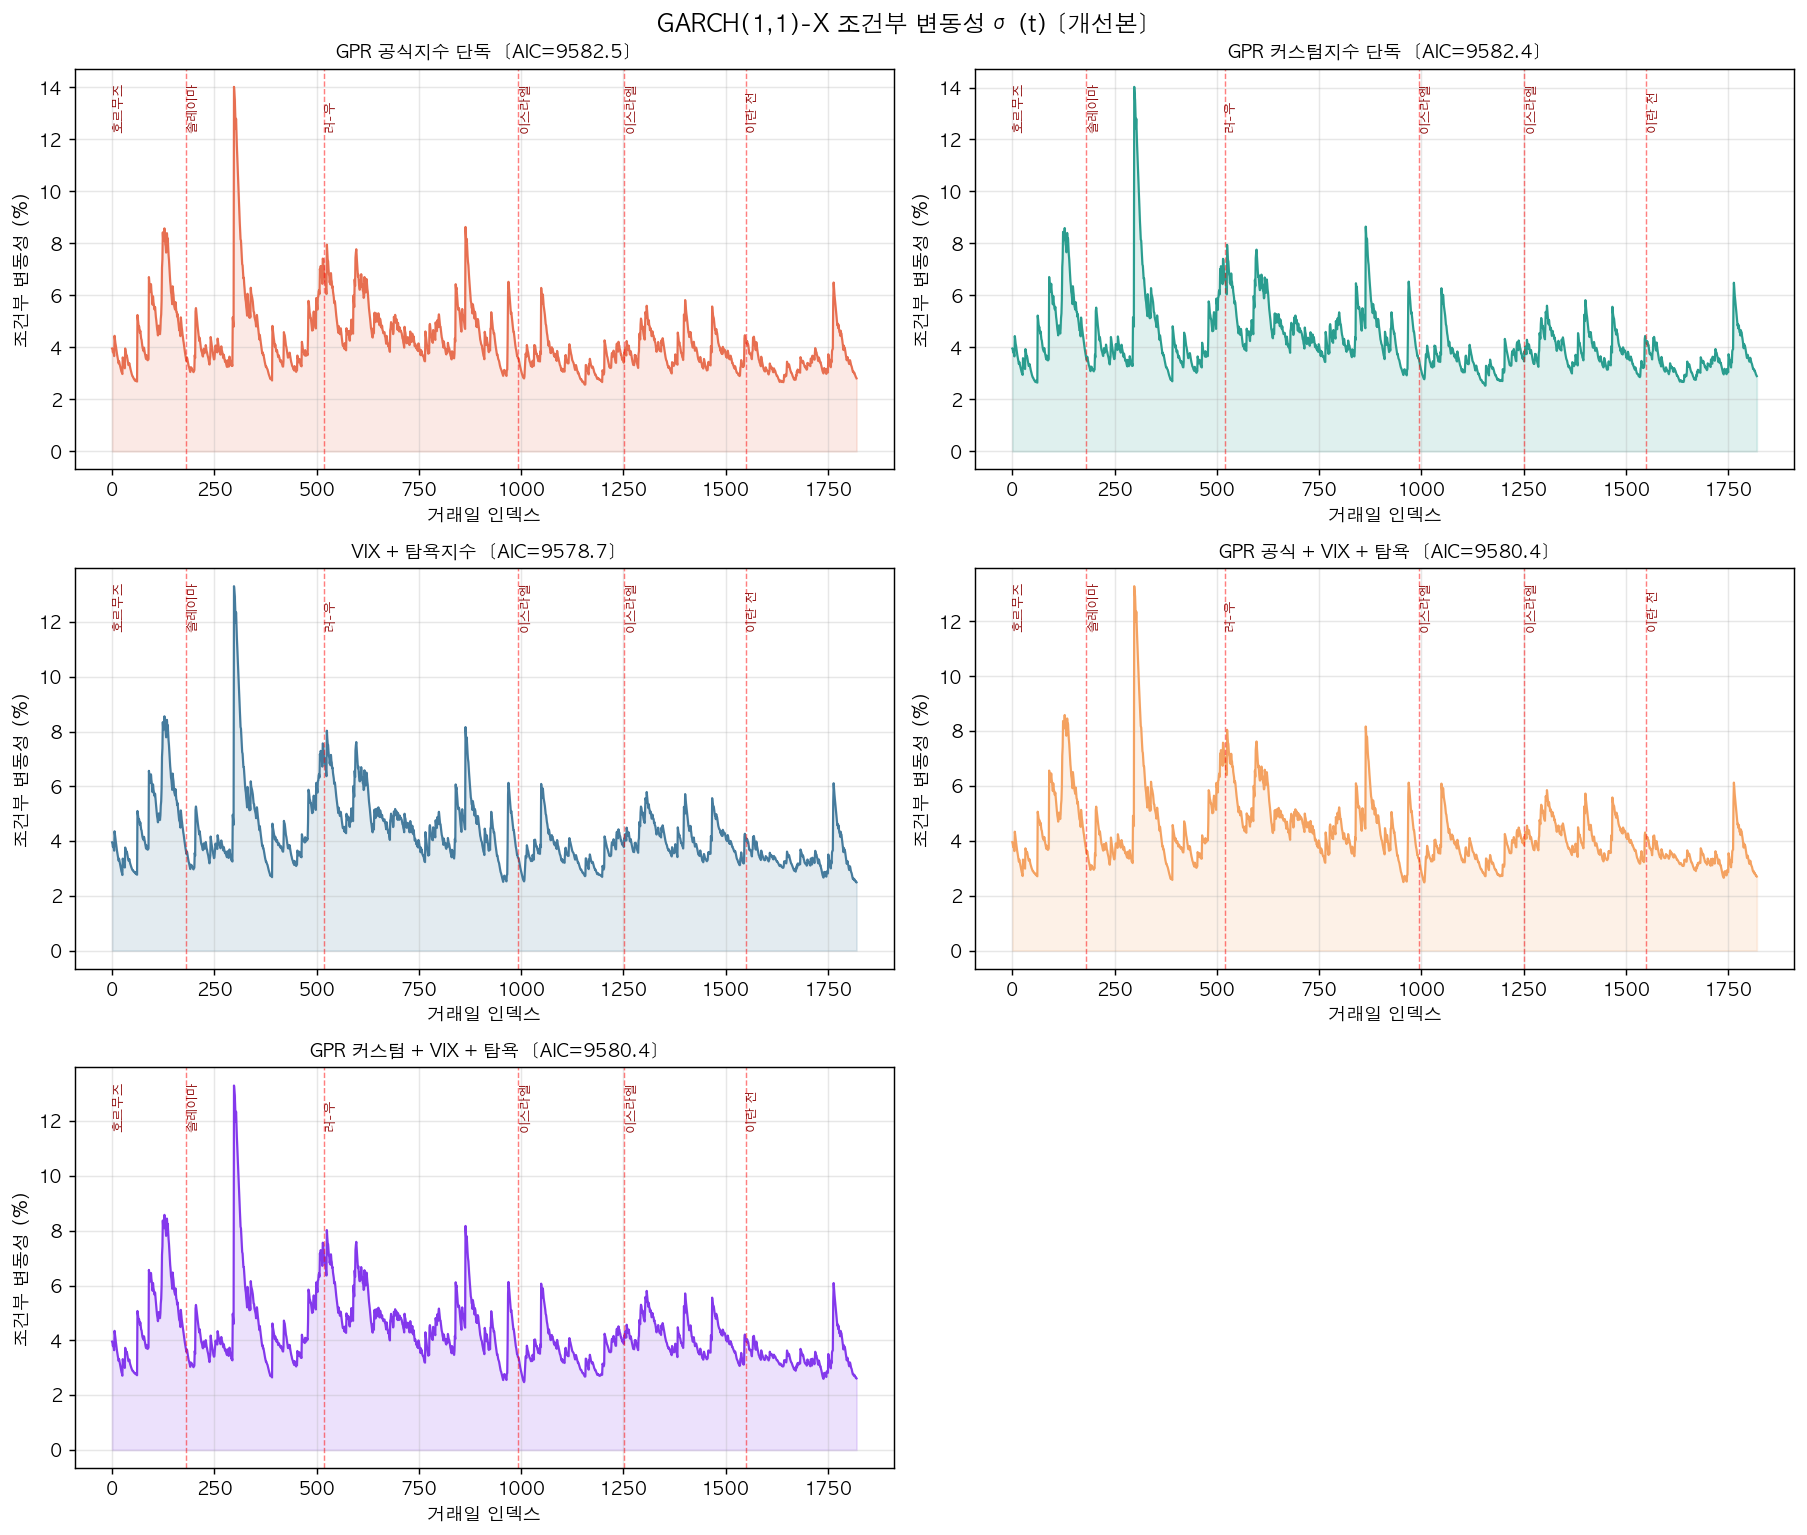

✅ garch_conditional_vol.png 저장


In [16]:
valid = [(m,r) for m,r in garch_results.items() if r.get('cond_vol') is not None]
n = len(valid)
cols_g = min(n,2); rows_g = (n+1)//2
fig, axes = plt.subplots(rows_g, cols_g, figsize=(14,4*rows_g), squeeze=False)
axes_flat = axes.flatten()

boundaries = []
cumsum = 0
for ev in EVENT_DATES:
    boundaries.append((cumsum, ev))
    cumsum += (master_final['event_name']==ev).sum()

for idx, (mname, res) in enumerate(valid):
    ax  = axes_flat[idx]
    cv  = res['cond_vol']
    clr = MODEL_COLORS.get(mname,'steelblue')
    ax.plot(cv, color=clr, lw=1.2)
    ax.fill_between(range(len(cv)), cv, alpha=0.15, color=clr)
    for pos, ev in boundaries[1:]:
        ax.axvline(pos, color='red', lw=0.8, ls='--', alpha=0.5)
    for pos, ev in boundaries:
        if pos < len(cv):
            ax.text(pos+0.5, cv.max()*0.88,
                    EVENT_LABELS.get(ev,ev)[:4],
                    fontsize=7, color='darkred', rotation=90)
    ax.set_title(f'{MODEL_LABELS.get(mname,mname)}  [AIC={res["aic"]:.1f}]',
                  fontsize=10, fontweight='bold')
    ax.set_xlabel('거래일 인덱스'); ax.set_ylabel('조건부 변동성 (%)')
    ax.grid(alpha=0.3)

for ax in axes_flat[len(valid):]: ax.set_visible(False)

plt.suptitle('GARCH(1,1)-X 조건부 변동성 σ(t) [개선본]',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('garch_conditional_vol.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ garch_conditional_vol.png 저장')

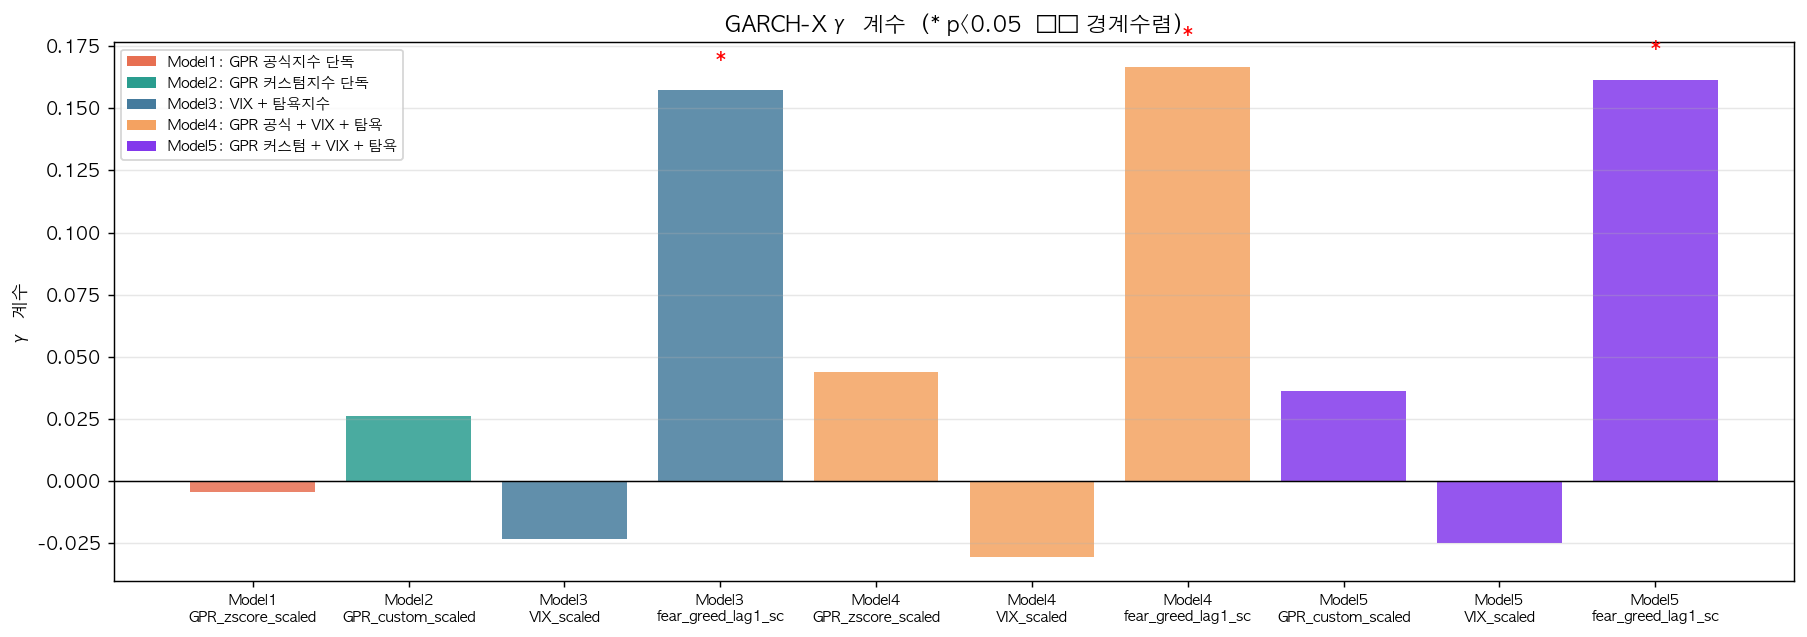

✅ garch_gamma_coefficients.png 저장


In [17]:
if len(gamma_df) > 0:
    fig, ax = plt.subplots(figsize=(14,5))
    clrs = [MODEL_COLORS.get(r['모델'],'gray') for _,r in gamma_df.iterrows()]
    bars = ax.bar(range(len(gamma_df)), gamma_df['γ'].values, color=clrs, alpha=0.85)
    for bar, (_,row) in zip(bars, gamma_df.iterrows()):
        if row['p-value'] < 0.05 and '⚠️' not in row['유의']:
            yoff = abs(bar.get_height())*0.05*(1 if bar.get_height()>=0 else -1)
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+yoff,'*',
                    ha='center', fontsize=14, color='red')
        if '⚠️' in str(row['유의']):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()*0.5,'⚠️',
                    ha='center', fontsize=10)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(range(len(gamma_df)))
    ax.set_xticklabels(
        [f'{r["모델"]}\n{r["변수"][:18]}' for _,r in gamma_df.iterrows()],
        fontsize=8)
    ax.set_ylabel('γ 계수')
    ax.set_title('GARCH-X γ 계수  (* p<0.05  ⚠️ 경계수렴)', fontsize=12)
    legend_els = [Patch(facecolor=v, label=f'{k}: {MODEL_LABELS[k]}')
                  for k,v in MODEL_COLORS.items()
                  if k in gamma_df['모델'].values]
    ax.legend(handles=legend_els, fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('garch_gamma_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ garch_gamma_coefficients.png 저장')

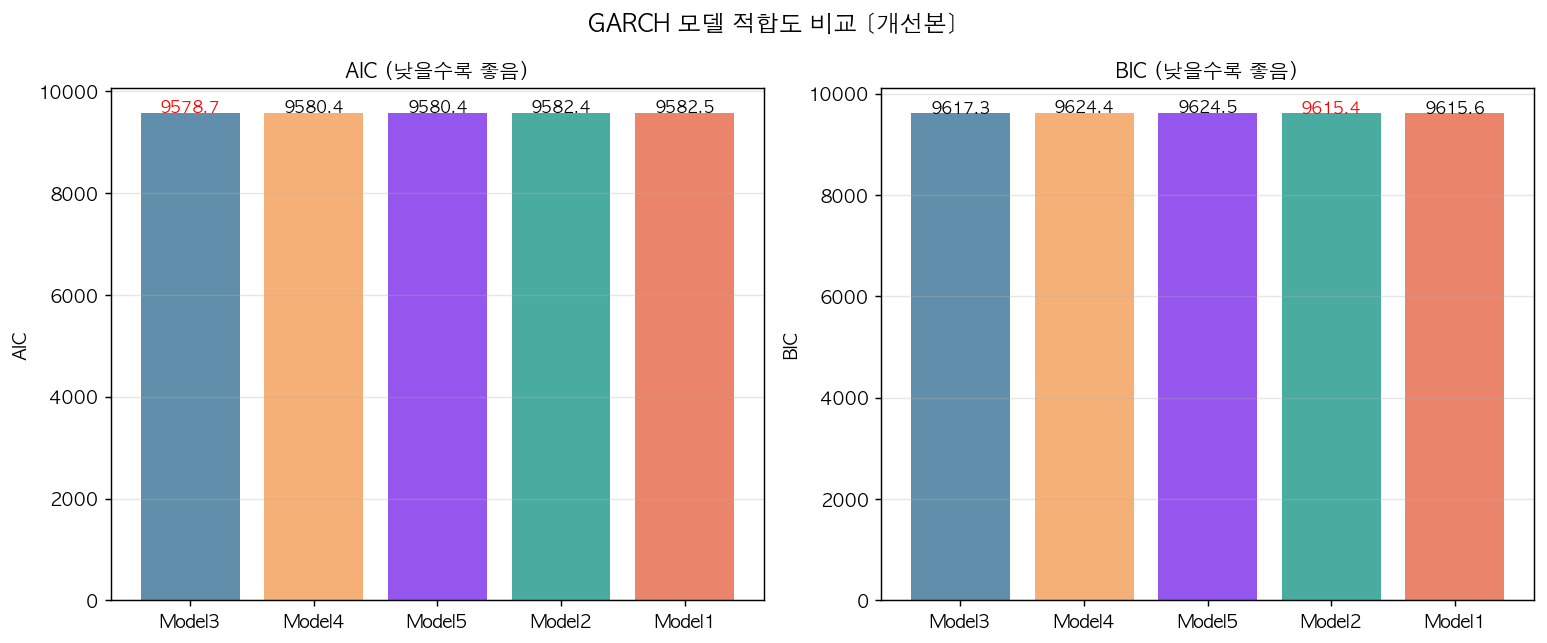

✅ garch_model_comparison.png 저장


In [18]:
if len(compare_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    for ax, metric in zip(axes, ['AIC','BIC']):
        vals  = compare_df[metric].values
        clrs2 = [MODEL_COLORS.get(m,'gray') for m in compare_df.index]
        bars  = ax.bar(compare_df.index, vals, color=clrs2, alpha=0.85)
        bv    = vals.min()
        for bar, val in zip(bars, vals):
            fc = 'red' if val==bv else 'black'
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.3,
                    f'{val:.1f}', ha='center', fontsize=9, color=fc)
        ax.set_title(f'{metric} (낮을수록 좋음)', fontsize=11)
        ax.set_ylabel(metric); ax.grid(axis='y', alpha=0.3)
    plt.suptitle('GARCH 모델 적합도 비교 [개선본]', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('garch_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ garch_model_comparison.png 저장')

---
## Step 8. 최종 결론 해석

In [19]:
print('='*70)
print('GARCH 분석 최종 결론 (한계점 개선본)')
print('='*70)

if len(compare_df) > 0:
    best = compare_df.index[0]
    print(f'\n✅ 최적 모델: {best}  ({MODEL_LABELS.get(best,best)})')
    print(f'   AIC={compare_df.loc[best,"AIC"]}  '
          f'BIC={compare_df.loc[best,"BIC"]}')

print('\n▶ GPR_custom γ 계수 (핵심 결과):')
for mname in ['Model2','Model5']:
    res = garch_results.get(mname)
    if res is None or res.get('stats') is None:
        print(f'  [{mname}] 결과 없음'); continue
    pnames = res['stats']['param_names']
    pvs    = res['stats']['p_values']
    tstats = res['stats']['t_stats']
    for pname, coef in res['params'].items():
        if 'GPR_custom' in pname and pname.startswith('gamma('):
            if pname in pnames:
                idx = pnames.index(pname)
                pv  = pvs[idx]; ts = tstats[idx]
                if abs(ts) > 100:
                    print(f'  [{mname}] γ={coef:+.4f}  ⚠️ t-stat 이상 (경계수렴)')
                else:
                    sig   = '유의 ✅' if pv<0.05 else '비유의 —'
                    direc = '증가→위험자산' if coef>0 else '감소→안전자산'
                    print(f'  [{mname}] γ={coef:+.4f}  p={pv:.4f}  {sig}')
                    print(f'          지정학 리스크↑ 시 BTC 변동성 {direc}')

print('\n▶ 개선 효과 요약:')
print('  [①②] bounds 조정 → omega=0 과적합 방지, alpha 경계 수렴 완화')
print('  [③]  numdifftools → SE 추정 정확도 향상 (p-value 보수성 감소)')
print('  [④]  다중 초기값 10개 → beta=0.30 국소최적해 문제 개선 가능성')
print('\n▶ 여전한 한계:')
print('  관측치 약 1,800행 (이벤트별 34~475행) → 검정력 근본적 부족')
print('  → 더 긴 시계열 또는 추가 이벤트 수집 시 재검증 필요')

GARCH 분석 최종 결론 (한계점 개선본)

✅ 최적 모델: Model3  (VIX + 탐욕지수)
   AIC=9578.71  BIC=9617.26

▶ GPR_custom γ 계수 (핵심 결과):
  [Model2] γ=+0.0263  p=0.7339  비유의 —
          지정학 리스크↑ 시 BTC 변동성 증가→위험자산
  [Model5] γ=+0.0364  p=0.5946  비유의 —
          지정학 리스크↑ 시 BTC 변동성 증가→위험자산

▶ 개선 효과 요약:
  [①②] bounds 조정 → omega=0 과적합 방지, alpha 경계 수렴 완화
  [③]  numdifftools → SE 추정 정확도 향상 (p-value 보수성 감소)
  [④]  다중 초기값 10개 → beta=0.30 국소최적해 문제 개선 가능성

▶ 여전한 한계:
  관측치 약 1,800행 (이벤트별 34~475행) → 검정력 근본적 부족
  → 더 긴 시계열 또는 추가 이벤트 수집 시 재검증 필요


---
## Step 9. 결과 저장

In [20]:
compare_df.to_csv('garch_model_comparison.csv', encoding='utf-8-sig')
if len(gamma_df) > 0:
    gamma_df.to_csv('garch_gamma_results.csv', index=False, encoding='utf-8-sig')

if len(compare_df) > 0:
    best_res = garch_results[compare_df.index[0]]
    if best_res.get('cond_vol') is not None:
        pd.DataFrame({
            'date'          : master_final['date'].values,
            'event_name'    : master_final['event_name'].values,
            'BTC_return_pct': master_final['returns_pct'].values,
            'cond_vol'      : best_res['cond_vol'],
        }).to_csv('garch_conditional_volatility.csv',
                   index=False, encoding='utf-8-sig')

print('▶ 최종 산출물:')
for f in ['garch_model_comparison.csv','garch_gamma_results.csv',
          'garch_conditional_volatility.csv','garch_conditional_vol.png',
          'garch_gamma_coefficients.png','garch_model_comparison.png']:
    flag = '✅' if os.path.exists(f) else '📄 (실행 후 생성)'
    print(f'  {flag} {f}')

▶ 최종 산출물:
  ✅ garch_model_comparison.csv
  ✅ garch_gamma_results.csv
  ✅ garch_conditional_volatility.csv
  ✅ garch_conditional_vol.png
  ✅ garch_gamma_coefficients.png
  ✅ garch_model_comparison.png
